# Mentor-Mentee Matching

Load survey CSVs, apply filters, score pairs, and review assignments.

In [15]:
from pathlib import Path
import pandas as pd

from csv_parse import parse_mentee_csv, parse_mentor_csv
from filters import apply_filters
from direct_match import build_ranked_pairs, greedy_assign


In [16]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')


In [17]:
# CSV locations (relative to this notebook)
base_dir = Path.cwd()
mentee_csv_path = base_dir / 'data/sample_mentees.csv'
mentor_csv_path = base_dir / 'data/sample_mentors.csv'


In [18]:
mentees = parse_mentee_csv(mentee_csv_path)
mentors = parse_mentor_csv(mentor_csv_path)
filtered_mentees, filtered_mentors = apply_filters(mentees, mentors)

ranked_pairs = build_ranked_pairs(filtered_mentees, filtered_mentors)
assignments = greedy_assign(ranked_pairs)

print('Mentees parsed:', len(mentees))
print('Mentees after filter:', len(filtered_mentees))
print('Mentors parsed:', len(mentors))
print('Ranked pairs:', len(ranked_pairs))
print('Assignments:', len(assignments))


Mentees parsed: 20
Mentees after filter: 16
Mentors parsed: 20
Ranked pairs: 320
Assignments: 16


In [19]:
ranked_df = pd.DataFrame(ranked_pairs)
assignments_df = pd.DataFrame(assignments)

ranked_df.head(10)


,mentee_email,mentee_name,mentor_email,mentor_name,major_overlap,education_overlap,score
0,mentee17@sample.edu,Mentee 17,mentor14@sample.edu,Mentor 14,3,1,7
1,mentee01@sample.edu,Mentee 01,mentor11@sample.edu,Mentor 11,3,0,6
2,mentee01@sample.edu,Mentee 01,mentor05@sample.edu,Mentor 05,2,1,5
3,mentee01@sample.edu,Mentee 01,mentor18@sample.edu,Mentor 18,2,1,5
4,mentee02@sample.edu,Mentee 02,mentor09@sample.edu,Mentor 09,2,1,5
5,mentee04@sample.edu,Mentee 04,mentor11@sample.edu,Mentor 11,2,1,5
6,mentee04@sample.edu,Mentee 04,mentor14@sample.edu,Mentor 14,2,1,5
7,mentee11@sample.edu,Mentee 11,mentor09@sample.edu,Mentor 09,2,1,5
8,mentee11@sample.edu,Mentee 11,mentor12@sample.edu,Mentor 12,2,1,5
9,mentee14@sample.edu,Mentee 14,mentor04@sample.edu,Mentor 04,2,1,5


In [20]:
assignments_df


,mentee_email,mentee_name,mentor_email,mentor_name,major_overlap,education_overlap,score
0,mentee17@sample.edu,Mentee 17,mentor14@sample.edu,Mentor 14,3,1,7
1,mentee01@sample.edu,Mentee 01,mentor11@sample.edu,Mentor 11,3,0,6
2,mentee02@sample.edu,Mentee 02,mentor09@sample.edu,Mentor 09,2,1,5
3,mentee11@sample.edu,Mentee 11,mentor12@sample.edu,Mentor 12,2,1,5
4,mentee14@sample.edu,Mentee 14,mentor04@sample.edu,Mentor 04,2,1,5
5,mentee19@sample.edu,Mentee 19,mentor18@sample.edu,Mentor 18,2,1,5
6,mentee03@sample.edu,Mentee 03,mentor10@sample.edu,Mentor 10,2,0,4
7,mentee04@sample.edu,Mentee 04,mentor03@sample.edu,Mentor 03,1,1,3
8,mentee07@sample.edu,Mentee 07,mentor07@sample.edu,Mentor 07,1,1,3
9,mentee09@sample.edu,Mentee 09,mentor05@sample.edu,Mentor 05,1,1,3


## Match Quality Visuals

Quick visuals to understand match scores and assignment quality.

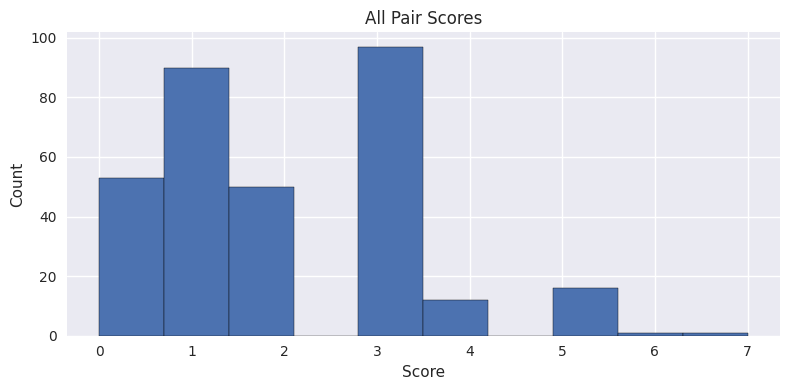

In [21]:
# Distribution of all pair scores
plt.figure(figsize=(8, 4))
ranked_df['score'].plot(kind='hist', bins=10, edgecolor='black')
plt.title('All Pair Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


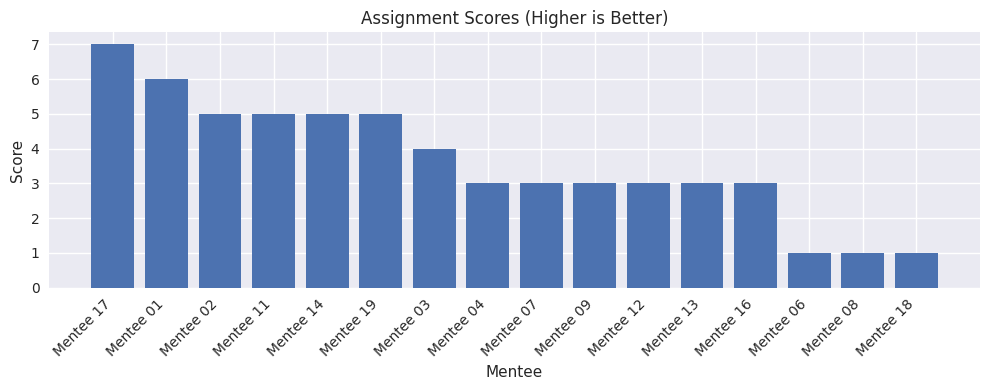

In [22]:
# Assignment scores (bar chart)
plt.figure(figsize=(10, 4))
assignments_df_sorted = assignments_df.sort_values('score', ascending=False)
plt.bar(assignments_df_sorted['mentee_name'], assignments_df_sorted['score'])
plt.title('Assignment Scores (Higher is Better)')
plt.xlabel('Mentee')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


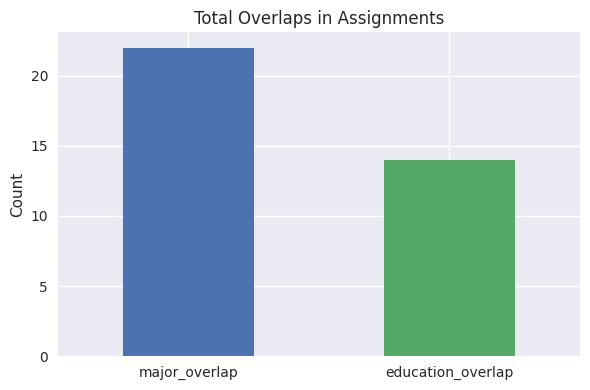

In [23]:
# Overlap breakdown for assignments
plt.figure(figsize=(6, 4))
assignments_df[['major_overlap', 'education_overlap']].sum().plot(kind='bar', color=['#4C72B0', '#55A868'])
plt.title('Total Overlaps in Assignments')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
